In [1]:
# Import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

## 1. Read data

In [2]:
df_success = pd.read_csv("../data/df_success.csv")
df_success.dtypes

Unnamed: 0       int64
Invoice          int64
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
Amount         float64
dtype: object

## 2.Phân cụm

### 2.1 Tiền xử lí dữ liệu

In [3]:
df_success["InvoiceDate"] = pd.to_datetime(df_success["InvoiceDate"])
now  = df_success["InvoiceDate"].max() + pd.Timedelta(days = 1)

In [4]:
customer = df_success.groupby("Customer ID").agg({
    "Country" : 'first',
    "InvoiceDate" : lambda x : (now - x.max()).days,
    "Amount" : "sum",
    "Invoice" : "nunique"
})
customer.columns = ["Country","Recency", "Monetary","Frequency"] 
customer.sort_values("Monetary", ascending = False).head(10)
customer_tmp = customer.copy()
customer.head()

,Country,Recency,Monetary,Frequency
Customer ID,,,,
12346.0,United Kingdom,165,372.86,11
12347.0,Iceland,3,1323.32,2
12348.0,Finland,74,222.16,1
12349.0,Italy,43,2671.14,3
12351.0,Unspecified,11,300.93,1


In [5]:
customer.to_csv("../data/customer.csv")

### 2.2 Phân cụm khách hàng

In [6]:
from sklearn.ensemble import IsolationForest

iso_forest = IsolationForest(contamination = 0.02, random_state = 42)
outlier_labels = iso_forest.fit_predict(customer_tmp[["Recency", "Frequency", "Monetary"]])
customer_tmp["Is_Outlier"] = outlier_labels
customer_tmp.sort_values("Monetary", ascending = False).head(5)

,Country,Recency,Monetary,Frequency,Is_Outlier
Customer ID,,,,,
18102.0,United Kingdom,1,349164.35,89,-1
14646.0,Netherlands,10,248396.50,78,-1
14156.0,EIRE,7,196566.74,102,-1
14911.0,EIRE,1,152147.57,205,-1
13694.0,United Kingdom,9,131443.19,94,-1


In [7]:
customer_tmp["Phan loai"] = np.nan
customer_tmp.head(2)

,Country,Recency,Monetary,Frequency,Is_Outlier,Phan loai
Customer ID,,,,,,
12346.0,United Kingdom,165,372.86,11,1,NaN
12347.0,Iceland,3,1323.32,2,1,NaN


In [8]:
# Scaler
from sklearn.preprocessing import StandardScaler
rfm_log = customer_tmp[customer_tmp["Is_Outlier"] == 1].copy()

rfm_log["Recency"] = np.log(rfm_log["Recency"]+1)
rfm_log["Frequency"] = np.log(rfm_log["Frequency"]+1)
rfm_log["Monetary"] = np.log(rfm_log["Monetary"]+1)

scaler = StandardScaler()
rfm_scalered = scaler.fit_transform(rfm_log[["Recency", "Frequency", "Monetary"]]) # Đưa về cùng thang đo
rfm_scalered = pd.DataFrame(rfm_scalered, columns = ["Recency", "Frequency", "Monetary"])
rfm_scalered.index = rfm_log.index
rfm_scalered.head()                                            

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,0.959933,1.853879,-0.517321
12347.0,-1.949913,-0.373177,0.538339
12348.0,0.339412,-1.024549,-0.948002
12349.0,-0.077106,0.088979,1.124257
12351.0,-1.091873,-1.024549,-0.695678


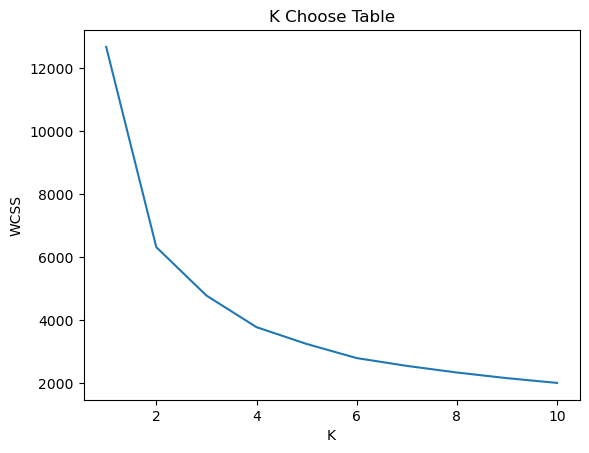

In [9]:
# Choose K for the algorithm
from sklearn.cluster import KMeans

wcss = []
K_range = range(1,11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state = 42, n_init = 10)
    kmeans.fit(rfm_scalered)
    wcss.append(kmeans.inertia_)

fig, ax = plt.subplots()
ax.plot(K_range, wcss)
ax.set(title = "K Choose Table",
        xlabel = "K",
        ylabel = "WCSS")
plt.show();

In [10]:
# Choose k = 3
kmeans = KMeans(n_clusters = 3)

kmeans.fit(rfm_scalered)

rfm_scalered["Phan loai"] = kmeans.labels_

In [11]:
rfm_scalered = rfm_scalered.reset_index()
rfm_scalered.head()

,Customer ID,Recency,Frequency,Monetary,Phan loai
0,12346.0,0.959933,1.853879,-0.517321,0
1,12347.0,-1.949913,-0.373177,0.538339,0
2,12348.0,0.339412,-1.024549,-0.948002,2
3,12349.0,-0.077106,0.088979,1.124257,0
4,12351.0,-1.091873,-1.024549,-0.695678,0


In [12]:
vip = customer_tmp[customer_tmp["Is_Outlier"] == -1].copy()
vip = vip.reset_index()
keep_columns = ["Customer ID","Phan loai"]
vip["Phan loai"] = 3
customer_combined = pd.concat([rfm_scalered,vip], axis =0 )
customer_combined = customer_combined[["Customer ID","Phan loai"]]
customer_combined[customer_combined["Phan loai"] == 2].head()

,Customer ID,Phan loai
2,12348.0,2
6,12353.0,2
7,12355.0,2
13,12361.0,2
14,12362.0,2


In [13]:
customer_tmp = customer_tmp.drop(["Phan loai","Is_Outlier","Country"], axis = 1)
customer_tmp = customer_tmp.merge(customer_combined, on = ["Customer ID"], how = "left")
customer_tmp = customer_tmp.set_index("Customer ID")
customer_tmp.head()

,Recency,Monetary,Frequency,Phan loai
Customer ID,,,,
12346.0,165,372.86,11,0
12347.0,3,1323.32,2,0
12348.0,74,222.16,1,2
12349.0,43,2671.14,3,0
12351.0,11,300.93,1,0


In [14]:
# Scaler
from sklearn.preprocessing import StandardScaler
rfm_log = customer_tmp.copy()

rfm_log["Recency"] = np.log(rfm_log["Recency"]+1)
rfm_log["Frequency"] = np.log(rfm_log["Frequency"]+1)
rfm_log["Monetary"] = np.log(rfm_log["Monetary"]+1)

scaler = StandardScaler()
rfm_scalered = scaler.fit_transform(rfm_log[["Recency", "Frequency", "Monetary"]]) # Đưa về cùng thang đo
rfm_scalered = pd.DataFrame(rfm_scalered, columns = ["Recency", "Frequency", "Monetary"])
rfm_scalered.index = rfm_log.index
rfm_scalered["Phan loai"] = customer_tmp["Phan loai"]
rfm_scalered.head()                                            

,Recency,Frequency,Monetary,Phan loai
Customer ID,,,,
12346.0,0.965369,1.613486,-0.535112,0
12347.0,-1.900370,-0.394241,0.447389,0
12348.0,0.354254,-0.981463,-0.935944,2
12349.0,-0.055950,0.022400,0.992701,0
12351.0,-1.055337,-0.981463,-0.701107,0


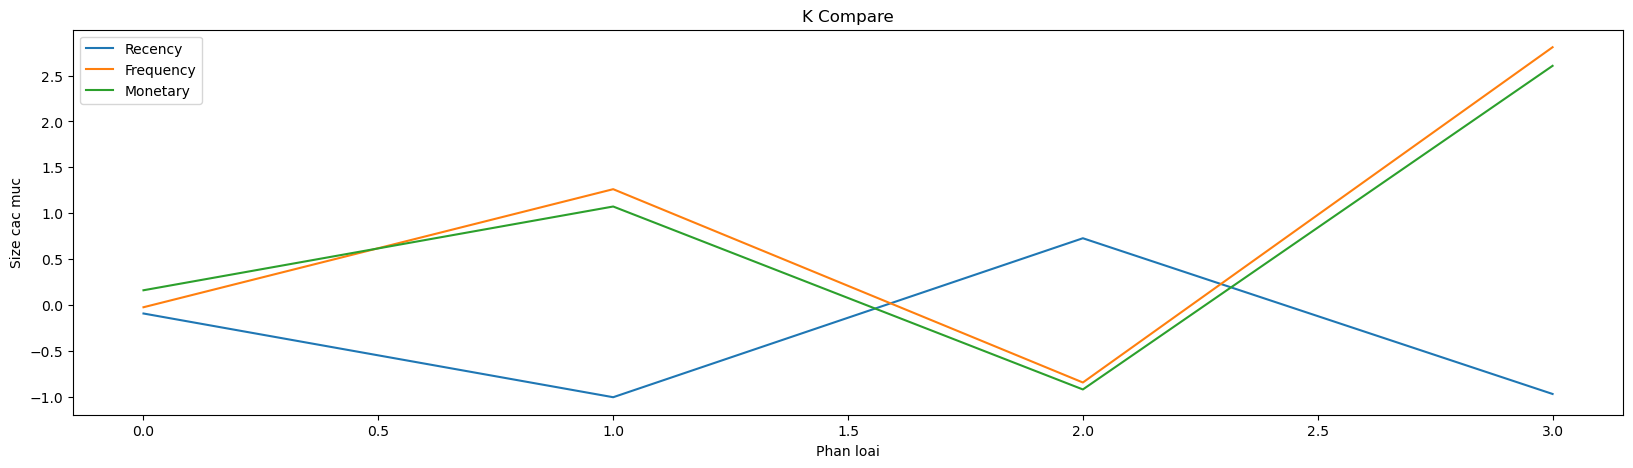

In [15]:
a = rfm_scalered.groupby("Phan loai").mean()
fig, ax = plt.subplots(figsize = (20,5))
ax.plot(a)
ax.set(title = "K Compare",
       xlabel = "Phan loai",
       ylabel = "Size cac muc")
ax.legend(a.columns)

#### Phan loai
1. R thap, F cao, M cao -> The Elite
2. R thap, F thap, M cao -> The High-Protential
3. R trung binh, F trung binh -> The Loyalists
4. R cao, F thap, M thap -> The need-attention

In [16]:
customer_tmp["Phan loai"] = customer_tmp["Phan loai"].replace({
    2 : "The need-attention",
    3 : "The Elite",
    0 : "The High-Protential",
    1 : "The Loyalists"
})
customer_tmp.head()

,Recency,Monetary,Frequency,Phan loai
Customer ID,,,,
12346.0,165,372.86,11,The High-Protential
12347.0,3,1323.32,2,The High-Protential
12348.0,74,222.16,1,The need-attention
12349.0,43,2671.14,3,The High-Protential
12351.0,11,300.93,1,The High-Protential


In [17]:
import joblib
joblib.dump({
    "model_loc_nhieu": iso_forest,
    "chuan_hoa": scaler,
    "phan_cum": kmeans
}, "../models/clustering.pkl")

['../models/clustering.pkl']